# Cellcharter

# Importing packages

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import cellcharter as cc
import matplotlib.pyplot as plt
import yaml
import squidpy as sq
from joblib import Parallel, delayed
from pathlib import Path

In [4]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
results_dir = Path(config['results_dir'])

In [43]:
#read the adata object
adata = ad.read(results_dir / 'adata_unified.h5ad')
adata.X = np.arcsinh(adata.X)
sc.pp.scale(adata)
adata.X = adata.X.astype(np.float32).copy()

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [44]:
model = cc.tl.TRVAE.load(
    'trvae', 
    adata, 
    map_location='cpu'
)

adata.obsm['X_trvae']= model.get_latent(adata.X, adata.obs['run'])

AnnData object with n_obs × n_vars = 521687 × 63
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [45]:
sq.gr.spatial_neighbors(adata, library_key='patient_exp', coord_type='generic', delaunay=True)

In [46]:
adata.uns["spatial"] = {roi: {} for roi in adata.obs['patient_exp'].unique()}


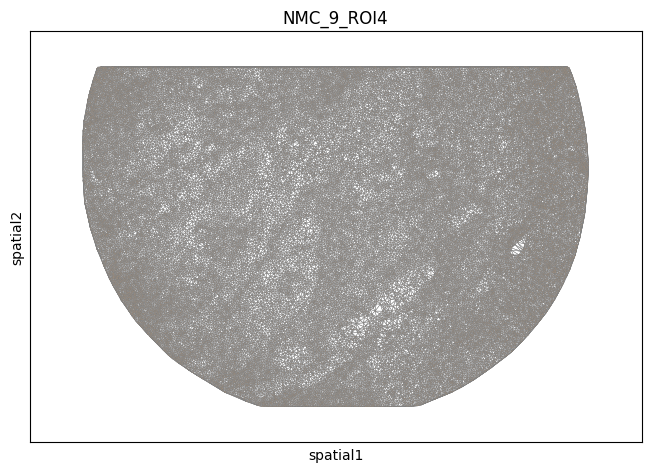

In [47]:
sq.pl.spatial_scatter(
    adata, 
    color='patient_exp', 
    library_key='patient_exp', 
    img=None, 
    title=['NMC_9_ROI4'],
    size=5,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['NMC_9_ROI4']
    )

In [48]:
cc.gr.remove_long_links(adata)

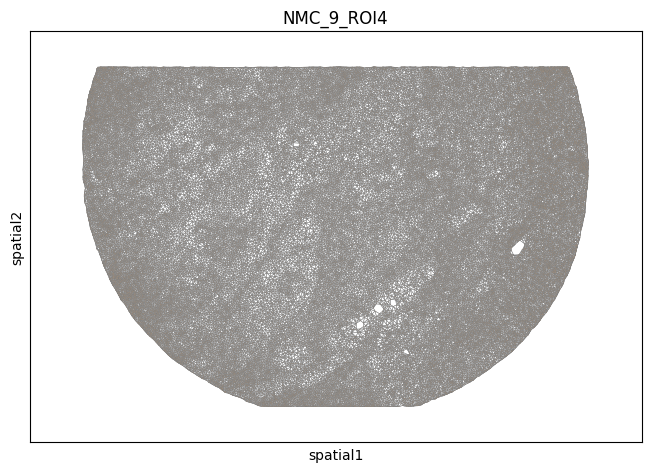

In [49]:
sq.pl.spatial_scatter(
    adata, 
    color='patient_exp', 
    library_key='patient_exp', 
    img=None, 
    title=['NMC_9_ROI4'],
    size=5,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['NMC_9_ROI4']
    )

In [50]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_trvae')

100%|██████████| 4/4 [00:00<00:00,  5.01it/s]


In [51]:
model_params = {
        'random_state': 1969,
        'trainer_params': {
            'accelerator':'cpu',
            'enable_progress_bar': True
        },
    }

In [52]:
autok = cc.tl.ClusterAutoK(n_clusters=(4,15), model_class=cc.tl.GaussianMixture, 
                           model_params=model_params, 
                           max_runs=5)

In [53]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/5


  0%|          | 0/14 [00:00<?, ?it/s]/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 19.91it/s]

  7%|▋         | 1/14 [00:05<01:09,  5.33s/it]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.29it/s]

...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  4.65it/s]

 93%|█████████▎| 13/14 [02:54<00:20, 20.23s/it]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  4.37it/s]

100%|██████████| 14/14 [03:12<00:00, 13.74s/it]

Convergence with a change in stability of 0.009212214973255155 reached after 5 iterations


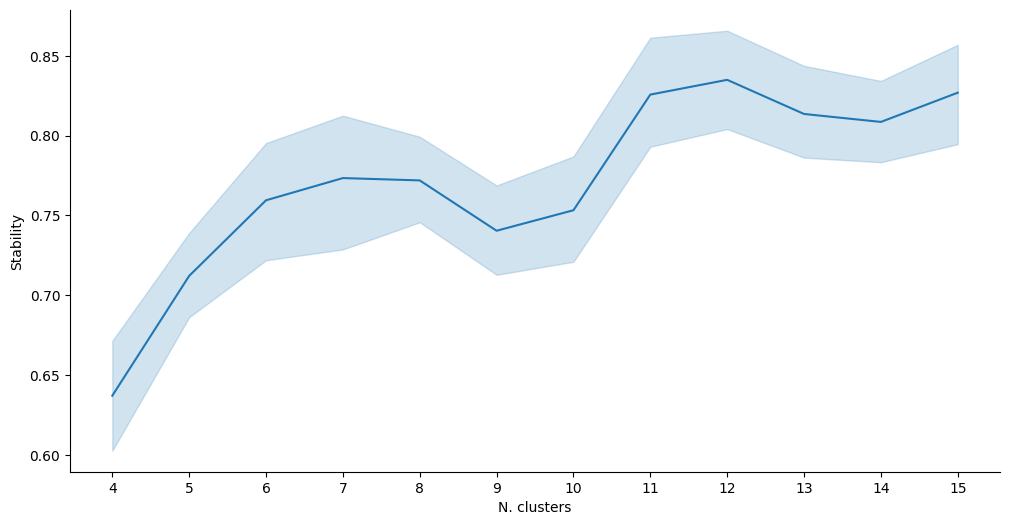

In [54]:
ax = cc.pl.autok_stability(autok, return_ax=True)
ax.figure.set_size_inches(12, 6) 

In [62]:
gmm = cc.tl.Cluster(
    n_clusters=8, 
    random_state=196979,
    trainer_params={'accelerator':'cpu',
                    'devices': 'auto',
                    'enable_progress_bar': True}
)

In [63]:
gmm.fit(adata, use_rep='X_cellcharter')
adata.obs['cellcharter_cluster'] = gmm.predict(adata, use_rep='X_cellcharter')

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Epoch 75: 100%|██████████| 1/1 [00:00<00:00,  5.56it/s, nll=16.00]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  9.08it/s]


In [64]:
cc.gr.enrichment(adata, group_key='cellcharter_cluster', label_key='cell_type', pvalues=True)


100%|██████████| 1000/1000 [00:21<00:00, 45.76it/s]


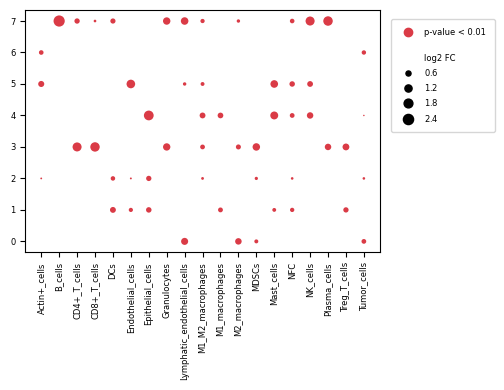

In [ ]:
cc.pl.enrichment(adata, group_key='cellcharter_cluster', label_key='cell_type', figsize=(4,4), fontsize=6, dot_scale=1, show_pvalues=True, group_cluster=False, significant_only=True, significance=0.01)

In [61]:
#write adata to desktop
adata.write("/Users/jawadalaaedeen/Desktop/adata_cellcharter.h5ad")

# The RADIUS ONE 


In [66]:
adata_radius = ad.read_h5ad("/Users/jawadalaaedeen/Desktop/adata_spatial.h5ad")

In [69]:
sq.gr.spatial_neighbors(adata_radius, library_key='patient_exp', coord_type='generic', delaunay=False, radius=180)

In [70]:
cc.gr.remove_long_links(adata_radius)

In [73]:
cc.gr.enrichment(adata_radius, group_key='neighborhood', label_key='cell_category', pvalues=True)


100%|██████████| 1000/1000 [00:24<00:00, 41.62it/s]


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_21605/1789266049.py:1: UserWarning: Significance requires show_pvalues=True. Ignoring significance.
  cc.pl.enrichment(adata_radius, group_key='neighborhood', label_key='cell_category', figsize=(4,4), fontsize=6, dot_scale=1, group_cluster=False, significant_only=True, significance=0.01)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_21605/1789266049.py:1: UserWarning: Significant_only requires significance to be set. Ignoring significant_only.
  cc.pl.enrichment(adata_radius, group_key='neighborhood', label_key='cell_category', figsize=(4,4), fontsize=6, dot_scale=1, group_cluster=False, significant_only=True, significance=0.01)


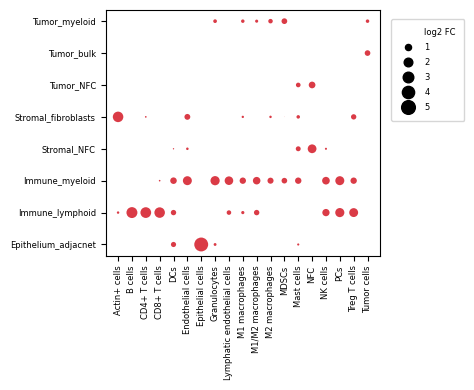

In [74]:
cc.pl.enrichment(adata_radius, group_key='neighborhood', label_key='cell_category', figsize=(4,4), fontsize=6, dot_scale=1, group_cluster=False, significant_only=True, significance=0.01)

In [77]:
cc.gr.nhood_enrichment(
    adata_radius,
    cluster_key='neighborhood',
    pvalues=False,
)

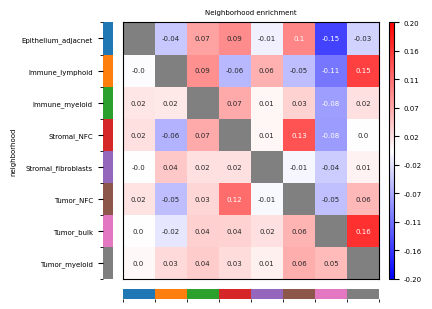

In [78]:
cc.pl.nhood_enrichment(
    adata_radius,
    cluster_key='neighborhood',
    annotate=True,
    figsize=(3,3),
    fontsize=5,
    vmin = -0.20,
    vmax = 0.20
    )

In [70]:
#Let's try this here....
adata = ad.read("/Users/jawadalaaedeen/Desktop/adata_spatial_final.h5ad")


/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [72]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

In [73]:
adata.raw = adata
adata.obsm["spatial"] = adata.obs[["Cell Center X", "Cell Center Y"]].values
adata.uns["spatial"] = {roi: {} for roi in adata.obs['patient_exp'].unique()}

In [74]:
#Let's build the squidpy graph...
sq.gr.spatial_neighbors(adata, library_key='patient_exp', coord_type='generic', delaunay=True)

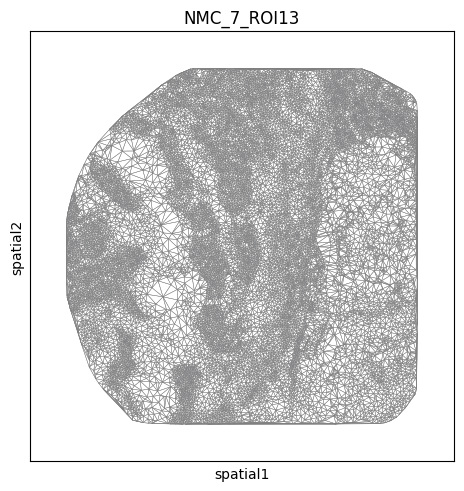

In [75]:
sq.pl.spatial_scatter(
    adata, 
    color='patient_exp', 
    library_key='patient_exp', 
    img=None, 
    title=['NMC_7_ROI13'],
    size=5,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['NMC_7_ROI13'],
    )

In [34]:
cc.gr.remove_long_links(adata)

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


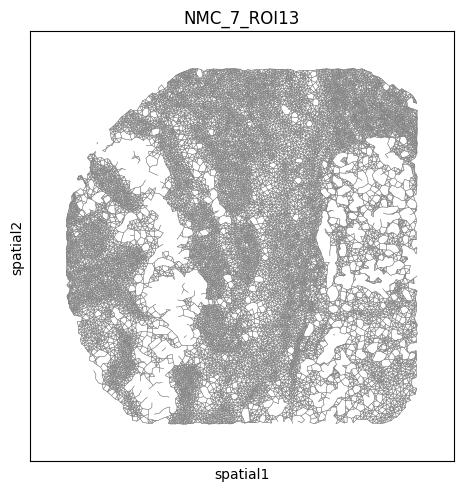

In [58]:
sq.pl.spatial_scatter(
    adata, 
    color='patient_exp', 
    library_key='patient_exp', 
    img=None, 
    title=['NMC_7_ROI13'],
    size=5,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['NMC_7_ROI13'],
    )

In [67]:
from scipy.spatial import Delaunay

In [99]:
def delaunay_adata_internal(adata, coords_key = "spatial", phenotype = "cell_category"):
    points = adata.obsm[coords_key]
    tri = Delaunay(points)
    neighbours_dict = {i: set() for i in range(len(points))}
    for simplex in tri.simplices:
                for i in range(len(simplex)):
                    for j in range(i + 1, len(simplex)):
                        neighbours_dict[simplex[i]].add(simplex[j])
                        neighbours_dict[simplex[j]].add(simplex[i])
    neighbours_list = [list(neighbours) for neighbours in neighbours_dict.values()]
    # Ensure each list has the same number of elements by padding with -1 (assuming indices are non-negative)
    max_neigh_len = max(len(neigh) for neigh in neighbours_list)
    neighbours_list_padded = [neigh + [-1] * (max_neigh_len - len(neigh)) for neigh in neighbours_list]
    # Convert to numpy array for consistency with KNN method
    ind = np.array(neighbours_list_padded)
    # Convert to DataFrame for the same output format as the original function
    neighbours = pd.DataFrame(ind.tolist(), index=adata.obs.index)
    # Replace -1 with None
    neighbours.replace(-1, None, inplace=True)
    phenomap = dict(zip(list(range(len(ind))), adata.obs[phenotype])) # Used for mapping
    for i in neighbours.columns:
            neighbours[i] = neighbours[i].dropna().map(phenomap, na_action='ignore')
    # Collapse all the neighbours into a single column
    n = pd.DataFrame(neighbours.stack(), columns = ["neighbour_phenotype"])
    n.index = n.index.get_level_values(0) # Drop the multi index
    n = pd.DataFrame(n)
    n['order'] = list(range(len(n)))
    # Merge with real phenotype
    n_m = n.merge(adata.obs[phenotype], how='inner', left_index=True, right_index=True)
    n_m['neighbourhood'] = n_m.index
    n = n_m.sort_values(by=['order'])
    # Normalize based on total cell count
    k = n.groupby(['neighbourhood','neighbour_phenotype']).size().unstack().fillna(0)
    # k = k.div(k.sum(axis=1), axis=0)    
    return k
def delaunay_adata(adata, coords_key = "spatial", phenotype = "cell_category", image_id = "patient_exp", label = "spatial_count"):
    adata_list = [adata[adata.obs[image_id] == i] for i in adata.obs[image_id].unique()]
    r_delaunay_data = lambda x: delaunay_adata_internal(x, coords_key="spatial", phenotype="cell_category")
    all_data = list(map(r_delaunay_data, adata_list))
    result = []
    for i in range(len(all_data)):
        result.append(all_data[i])
    result = pd.concat(result, join='outer') 
    # Reindex the cells
    result = result.reindex(adata.obs.index)
    result = result.fillna(0)

    # Add to adata
    adata.uns[label] = result
    
    # Return        
    return adata


In [100]:
adata = delaunay_adata(adata)

In [102]:
adata.uns["spatial_count"]

neighbour_phenotype,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,MDSCs,Mast cells,NFC,NK cells,PCs,Treg T cells,Tumor cells,Epithelial cells
373491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
67000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0
66999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
66998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
66997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80785,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0
80786,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
80787,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
80789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0


In [49]:
cc.gr.nhood_enrichment(
    adata,
    cluster_key='neighborhood',
    pvalues=False,
)

In [50]:
adata.uns["neighborhood_nhood_enrichment"]["enrichment"]

,Epithelial_adjacent,Lymphatic_immune,Lymphoid_B,Lymphoid_T,Myeloid_granulocytes_MDSCs,Stromal_NFC,Stromal_fibroblasts,Tumor_NFC,Tumor_bulk,Tumor_myeloid,Vascular/Endothelial
Epithelial_adjacent,NaN,0.078635,-0.010415,-0.018550,0.060313,0.033818,-0.043850,0.079401,-0.274887,0.094507,0.020068
Lymphatic_immune,-0.001447,NaN,0.014160,0.092045,0.030868,0.006939,0.044076,0.004576,-0.302374,0.140657,0.030012
Lymphoid_B,-0.015712,0.210110,NaN,0.376847,-0.017464,-0.077710,0.045967,-0.075421,-0.319171,-0.114357,-0.000035
Lymphoid_T,-0.007243,0.257371,0.077214,NaN,0.003294,-0.014301,0.130772,-0.053340,-0.311567,-0.037336,0.019372
Myeloid_granulocytes_MDSCs,0.010136,0.096942,-0.009299,-0.020633,NaN,-0.004608,-0.019059,-0.021189,-0.267957,0.271666,-0.003463
Stromal_NFC,-0.002987,0.043749,-0.009877,-0.022195,0.005342,NaN,0.047065,0.438063,-0.310249,-0.120734,0.046623
Stromal_fibroblasts,-0.016130,0.073539,0.000615,0.054974,-0.010684,0.046478,NaN,0.003240,-0.273862,0.121111,0.062797
Tumor_NFC,-0.007544,-0.006709,-0.011766,-0.052499,-0.016366,0.203381,-0.020483,NaN,-0.099312,0.119220,-0.007057
Tumor_bulk,-0.016378,-0.050296,-0.012843,-0.061618,-0.022874,-0.107880,-0.045059,0.089840,NaN,0.581379,-0.030206
Tumor_myeloid,-0.008915,0.033684,-0.011280,-0.044310,0.020979,-0.096327,0.007652,0.072539,0.202885,NaN,-0.003341


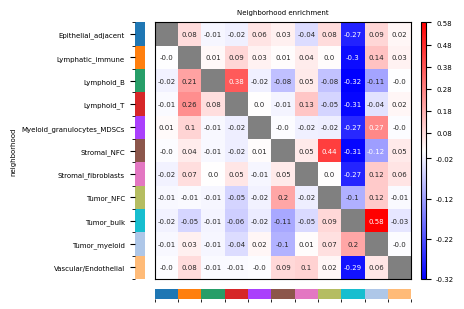

In [51]:
cc.pl.nhood_enrichment(
    adata,
    cluster_key='neighborhood',
    annotate=True,
    figsize=(3,3),
    fontsize=5,
    )

In [83]:
from cellcharter.gr import nhood_enrichment

results_per_patient = {}

for patient in adata.obs["patient_exp"].unique():

    ad = adata[adata.obs["patient_exp"] == patient].copy()

    cc.gr.nhood_enrichment(
    ad,
    cluster_key='neighborhood',
    pvalues=False,
)
    res = ad.uns["neighborhood_nhood_enrichment"]["enrichment"]

    results_per_patient[patient] = res

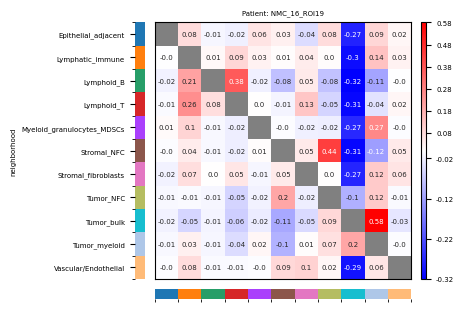

In [90]:
cc.gr.nhood_enrichment(
adata,
cluster_key='neighborhood',
pvalues=False,
)
    
cc.pl.nhood_enrichment(
adata,
cluster_key='neighborhood',
annotate=True,
figsize=(3,3),
fontsize=5,
title=f"Patient: {patient}"
)

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/cellcharter/pl/_utils.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(constrained_layout=True, dpi=dpi, figsize=figsize)


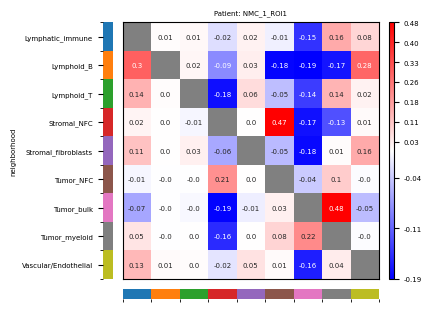

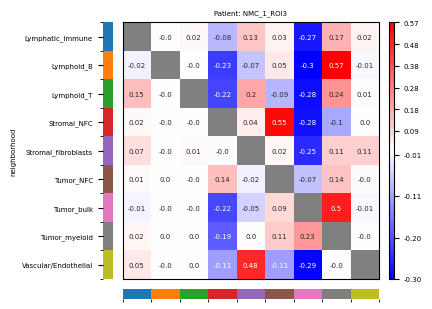

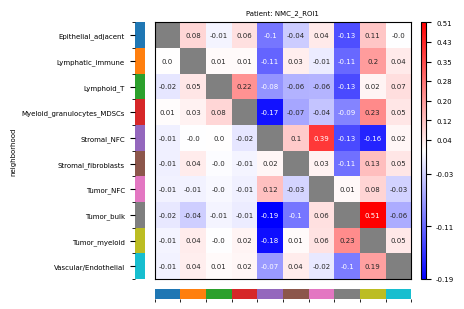

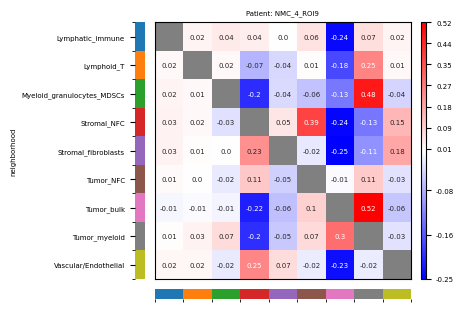

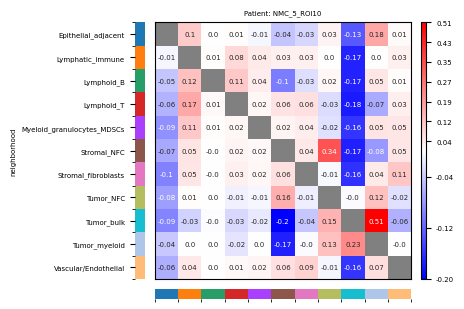

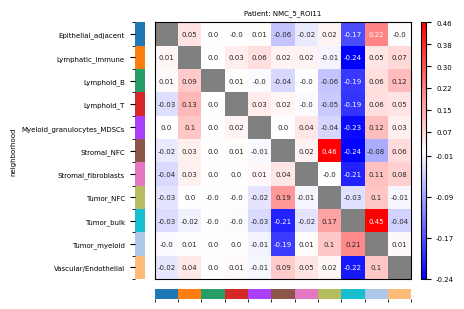

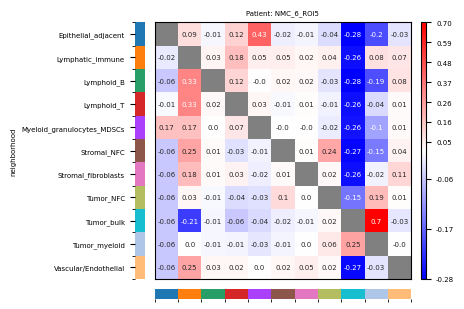

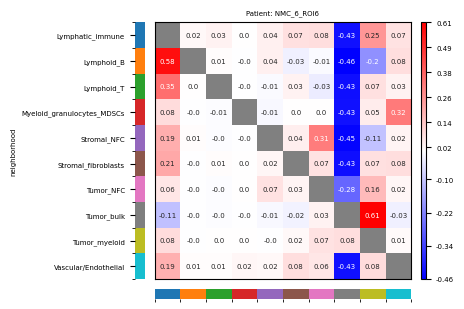

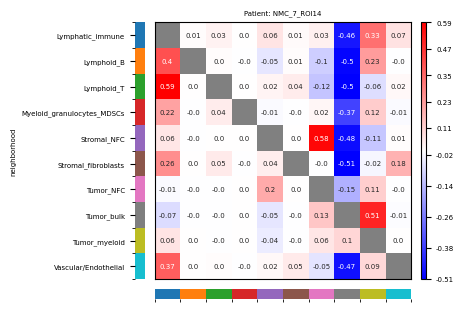

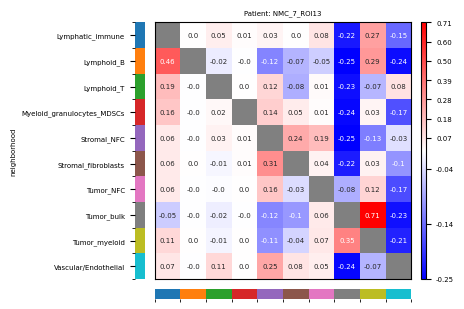

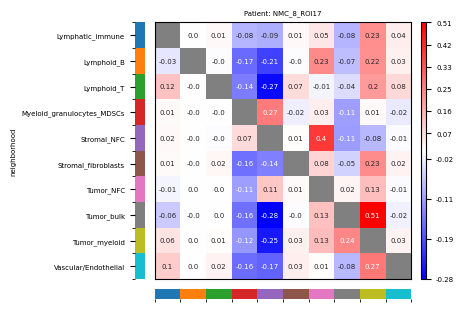

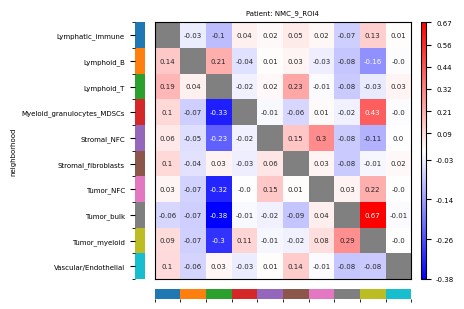

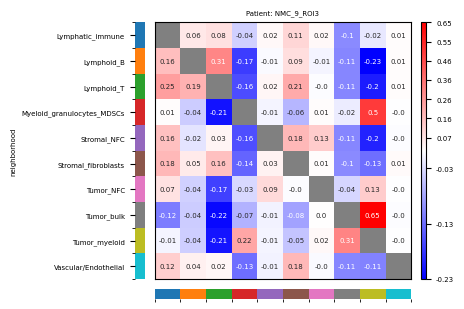

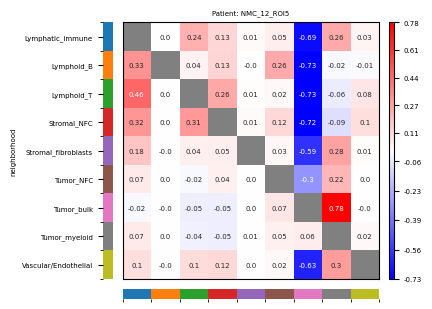

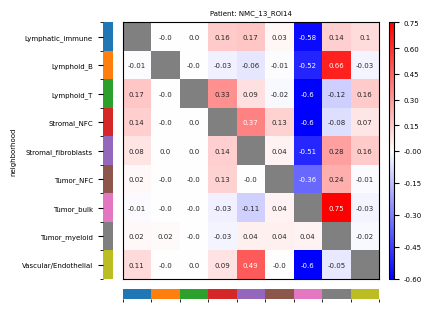

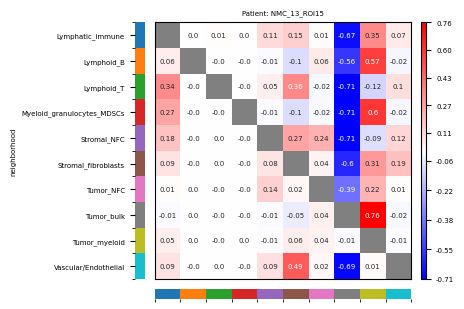

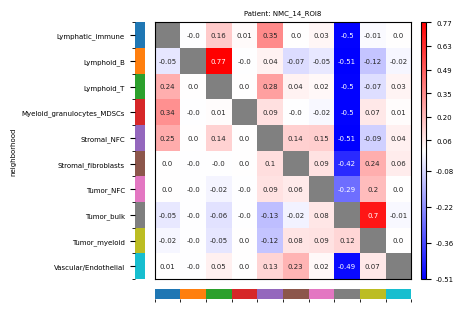

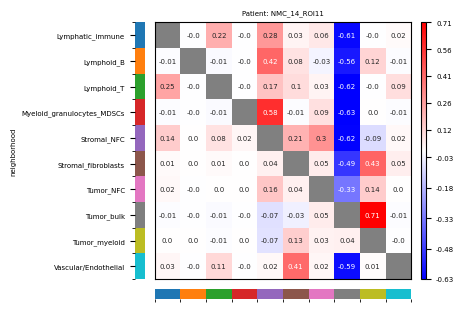

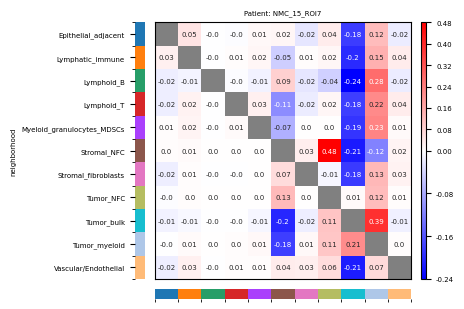

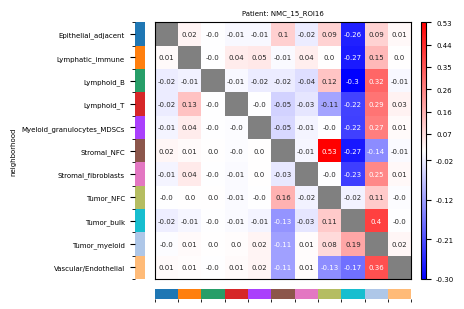

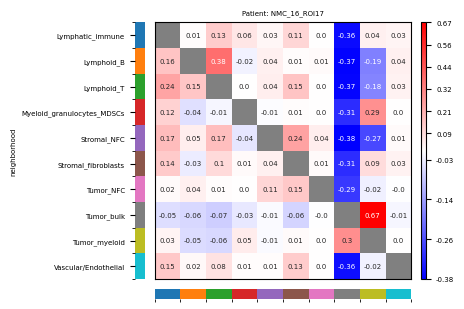

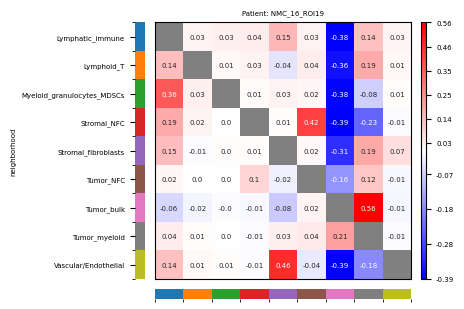

In [89]:
from cellcharter.gr import nhood_enrichment

for patient in adata.obs["patient_exp"].unique():

    ad = adata[adata.obs["patient_exp"] == patient].copy()

    cc.gr.nhood_enrichment(
    ad,
    cluster_key='neighborhood',
    pvalues=False,
)
    
    cc.pl.nhood_enrichment(
    ad,
    cluster_key='neighborhood',
    annotate=True,
    figsize=(3,3),
    fontsize=5,
    title=f"Patient: {patient}"
    )

In [86]:
import seaborn as sns
# make results per patient into a dataframe
results_df = pd.concat(results_per_patient, axis=0)
#make this long data
results_df = results_df.reset_index()
#make it long and call them level_2
results_df = results_df.melt(id_vars=["level_0", "level_1"], var_name="neighbour_phenotype", value_name="enrichment")
results_df
#per patient heatmap 
plt.figure(figsize=(10,10))

,level_0,level_1,neighbour_phenotype,enrichment
0,NMC_1_ROI1,Lymphatic_immune,Lymphatic_immune,NaN
1,NMC_1_ROI1,Lymphoid_B,Lymphatic_immune,0.297193
2,NMC_1_ROI1,Lymphoid_T,Lymphatic_immune,0.142874
3,NMC_1_ROI1,Stromal_NFC,Lymphatic_immune,0.019658
4,NMC_1_ROI1,Stromal_fibroblasts,Lymphatic_immune,0.111798
...,...,...,...,...
2404,NMC_16_ROI19,Stromal_fibroblasts,Myeloid_granulocytes_MDSCs,0.004993
2405,NMC_16_ROI19,Tumor_NFC,Myeloid_granulocytes_MDSCs,0.001840
2406,NMC_16_ROI19,Tumor_bulk,Myeloid_granulocytes_MDSCs,-0.003788
2407,NMC_16_ROI19,Tumor_myeloid,Myeloid_granulocytes_MDSCs,0.000317
